In [ ]:
import torch
torch.cuda.get_device_name(0)


'NVIDIA A100-SXM4-80GB'

In [ ]:
import os
import numpy as np
import pandas as pd
from skimage.io import imread
from scipy.stats import spearmanr

def dice_score(gt, pred):
    gt = gt > 0
    pred = pred > 0

    intersection = np.logical_and(gt, pred).sum()
    return (2. * intersection) / (gt.sum() + pred.sum() + 1e-8)

gt_folder = "gt_masks"
pred_folder = "pred_masks"

results = []

for filename in os.listdir(gt_folder):
    if filename.endswith(".png"):

        gt = imread(os.path.join(gt_folder, filename))
        pred = imread(os.path.join(pred_folder, filename))

        area = (gt > 0).sum()
        dice = dice_score(gt, pred)

        results.append({
            "slice": filename,
            "area": area,
            "dice": dice
        })

df = pd.DataFrame(results)
df.to_csv("tumor_area_dice_analysis.csv", index=False)

print("Saved analysis CSV.")

FileNotFoundError: [Errno 2] No such file or directory: 'gt_masks'

In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    if "gt" in root.lower():
        print(root)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
# ---- 1) Basic setup ----
!pip -q install -U pip

# ---- 2) Core scientific stack ----
!pip -q install numpy pandas scipy matplotlib opencv-python scikit-image tqdm

# ---- 3) Medical imaging (BraTS uses NIfTI) ----
!pip -q install nibabel

# ---- 4) Install Segment Anything (SAM) ----
!git clone -q https://github.com/facebookresearch/segment-anything.git
%cd segment-anything
!pip -q install -e .

# ---- 5) Verify GPU + torch ----
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 50.2 MB/s eta 0:00:00
/content/segment-anything
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for segment_anything (pyproject.toml) ... done
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
# Download SAM ViT-B checkpoint (recommended for speed)
!mkdir -p checkpoints
!wget -q --show-progress -O checkpoints/sam_vit_b_01ec64.pth \
  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

# Quick sanity check (file size should be ~375MB)
!ls -lh checkpoints/sam_vit_b_01ec64.pth


checkpoints/sam_vit 100%[===================>] 357.67M   485MB/s    in 0.7s    
-rw-r--r-- 1 root root 358M Apr  4  2023 checkpoints/sam_vit_b_01ec64.pth


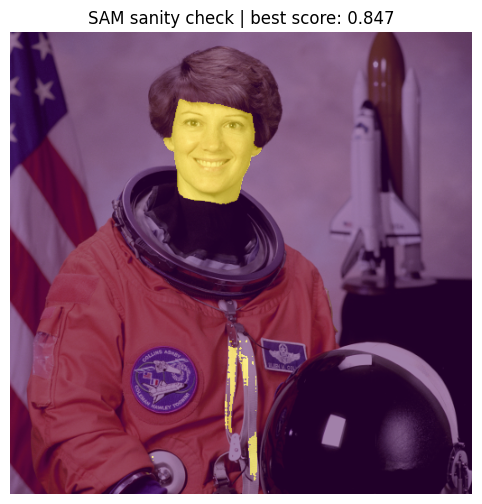

Masks shape: (3, 512, 512) Scores: [0.77318156 0.7788704  0.84701335]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
import torch

from segment_anything import sam_model_registry, SamPredictor

# 1) Load a sample image (built-in, no downloads)
img = data.astronaut()  # shape (H,W,3), uint8

# 2) Load SAM (ViT-B) checkpoint
sam_checkpoint = "checkpoints/sam_vit_b_01ec64.pth"
model_type = "vit_b"
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

predictor = SamPredictor(sam)
predictor.set_image(img)

# 3) Give a simple bounding box prompt (x0,y0,x1,y1)
H, W = img.shape[:2]
box = np.array([W*0.25, H*0.15, W*0.75, H*0.95], dtype=np.float32)

masks, scores, logits = predictor.predict(
    box=box,
    multimask_output=True
)

best = np.argmax(scores)
mask = masks[best]

# 4) Visualize result
plt.figure(figsize=(8,6))
plt.imshow(img)
plt.imshow(mask, alpha=0.5)
plt.title(f"SAM sanity check | best score: {scores[best]:.3f}")
plt.axis("off")
plt.show()

print("Masks shape:", masks.shape, "Scores:", scores)


In [ ]:
# We are currently in /content/segment-anything
%cd /content

# Download MSD Task01 BrainTumour (BraTS-derived)
!wget -q --show-progress -O Task01_BrainTumour.tar \
  https://msd-for-monai.s3-us-west-2.amazonaws.com/Task01_BrainTumour.tar

# Check file size
!ls -lh Task01_BrainTumour.tar


/content
Task01_BrainTumour. 100%[===================>]   7.08G  11.9MB/s    in 10m 39s 
-rw-r--r-- 1 root root 7.1G Aug 14  2020 Task01_BrainTumour.tar


In [ ]:
%cd /content

# Extract
!tar -xf Task01_BrainTumour.tar

# Verify structure
!ls -lah Task01_BrainTumour | head
!ls -lah Task01_BrainTumour/imagesTr | head
!ls -lah Task01_BrainTumour/labelsTr | head


/content
total 124K
drwxr-xr-x 5 root root  4.0K Feb 19 05:08 .
drwxr-xr-x 1 root root  4.0K Feb 19 05:08 ..
-rwxr-xr-x 1  502 staff  384 Jul  3  2018 ._dataset.json
-rwxr-xr-x 1  502 staff  46K Jul  3  2018 dataset.json
-rwxr-xr-x 1  502 staff  120 May 15  2018 ._imagesTr
drwxr-xr-x 2  502 staff  20K May 15  2018 imagesTr
-rwxr-xr-x 1  502 staff  120 May 26  2018 ._imagesTs
drwxr-xr-x 2  502 staff  12K May 26  2018 imagesTs
-rwxr-xr-x 1  502 staff  120 Jul  3  2018 ._labelsTr
total 4.5G
drwxr-xr-x 2  502 staff  20K May 15  2018 .
drwxr-xr-x 5 root root  4.0K Feb 19 05:08 ..
-rwxr-xr-x 1  502 staff  176 May 10  2018 ._BRATS_001.nii.gz
-rwxr-xr-x 1  502 staff  11M May 10  2018 BRATS_001.nii.gz
-rwxr-xr-x 1  502 staff  176 May 10  2018 ._BRATS_002.nii.gz
-rwxr-xr-x 1  502 staff  11M May 10  2018 BRATS_002.nii.gz
-rwxr-xr-x 1  502 staff  12M May 10  2018 BRATS_003.nii.gz
-rwxr-xr-x 1  502 staff  176 May 10  2018 ._BRATS_004.nii.gz
-rwxr-xr-x 1  502 staff 8.7M May 10  2018 BRATS_004.nii.gz

In [ ]:
%cd /content

# List real folders (not the "._" ones)
!ls -lah Task01_BrainTumour | sed -n '1,40p'

# Count training images and labels
!ls Task01_BrainTumour/imagesTr/*.nii.gz | wc -l
!ls Task01_BrainTumour/labelsTr/*.nii.gz | wc -l

# Show a few filenames
!ls Task01_BrainTumour/imagesTr/*.nii.gz | head -n 5
!ls Task01_BrainTumour/labelsTr/*.nii.gz | head -n 5


/content
total 124K
drwxr-xr-x 5 root root  4.0K Feb 19 05:08 .
drwxr-xr-x 1 root root  4.0K Feb 19 05:08 ..
-rwxr-xr-x 1  502 staff  384 Jul  3  2018 ._dataset.json
-rwxr-xr-x 1  502 staff  46K Jul  3  2018 dataset.json
-rwxr-xr-x 1  502 staff  120 May 15  2018 ._imagesTr
drwxr-xr-x 2  502 staff  20K May 15  2018 imagesTr
-rwxr-xr-x 1  502 staff  120 May 26  2018 ._imagesTs
drwxr-xr-x 2  502 staff  12K May 26  2018 imagesTs
-rwxr-xr-x 1  502 staff  120 Jul  3  2018 ._labelsTr
drwxr-xr-x 2  502 staff  20K Jul  3  2018 labelsTr
484
484
Task01_BrainTumour/imagesTr/BRATS_001.nii.gz
Task01_BrainTumour/imagesTr/BRATS_002.nii.gz
Task01_BrainTumour/imagesTr/BRATS_003.nii.gz
Task01_BrainTumour/imagesTr/BRATS_004.nii.gz
Task01_BrainTumour/imagesTr/BRATS_005.nii.gz
Task01_BrainTumour/labelsTr/BRATS_001.nii.gz
Task01_BrainTumour/labelsTr/BRATS_002.nii.gz
Task01_BrainTumour/labelsTr/BRATS_003.nii.gz
Task01_BrainTumour/labelsTr/BRATS_004.nii.gz
Task01_BrainTumour/labelsTr/BRATS_005.nii.gz


Image shape: (240, 240, 155, 4) Label shape: (240, 240, 155)
Chosen slice z: 63 tumor pixels: 2458
Box: [ 64. 127. 173. 191.]
Scores: [0.9314001 0.9424323 0.9285569] Best: 0.9424323 Dice: 0.8662374821157613


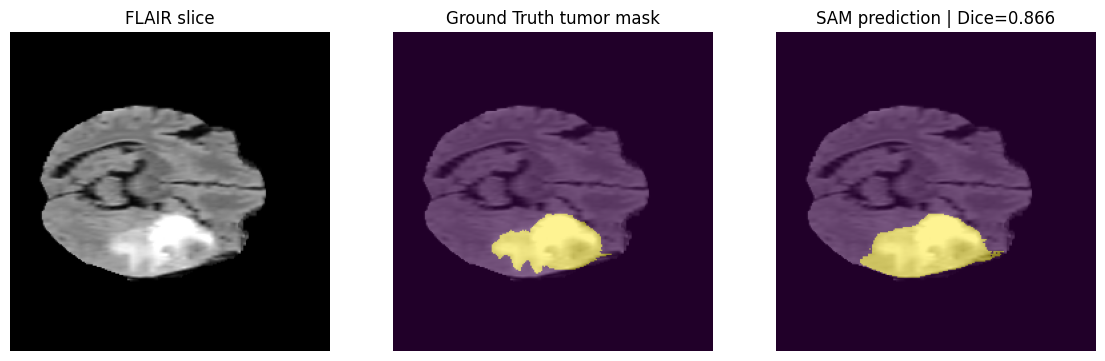

In [ ]:
import os, glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import torch

from segment_anything import sam_model_registry, SamPredictor

# ---- Paths ----
img_path = "/content/Task01_BrainTumour/imagesTr/BRATS_001.nii.gz"
lbl_path = "/content/Task01_BrainTumour/labelsTr/BRATS_001.nii.gz"

# ---- Load volumes ----
img_nii = nib.load(img_path)
lbl_nii = nib.load(lbl_path)

img = img_nii.get_fdata()   # shape: (H, W, Z, C) in this dataset
lbl = lbl_nii.get_fdata()   # shape: (H, W, Z)

print("Image shape:", img.shape, "Label shape:", lbl.shape)

# ---- Pick FLAIR channel (commonly channel 0 in this dataset) ----
# MSD Task01 typically stores 4 MRI modalities as last dimension C=4.
flair = img[..., 0]

# ---- Find a slice with tumor ----
tumor = (lbl > 0).astype(np.uint8)   # binary mask
slice_sums = tumor.sum(axis=(0,1))
z = int(np.argmax(slice_sums))
print("Chosen slice z:", z, "tumor pixels:", int(slice_sums[z]))

flair_slice = flair[..., z]
mask_slice = tumor[..., z]

# ---- Normalize slice to uint8 0-255 ----
p1, p99 = np.percentile(flair_slice, (1, 99))
flair_norm = np.clip((flair_slice - p1) / (p99 - p1 + 1e-8), 0, 1)
img_u8 = (flair_norm * 255).astype(np.uint8)

# SAM expects 3-channel RGB
img_rgb = np.stack([img_u8]*3, axis=-1)

# ---- Compute bounding box from GT mask ----
ys, xs = np.where(mask_slice > 0)
y0, y1 = ys.min(), ys.max()
x0, x1 = xs.min(), xs.max()

# Add padding
pad = 10
H, W = mask_slice.shape
x0 = max(0, x0 - pad); y0 = max(0, y0 - pad)
x1 = min(W-1, x1 + pad); y1 = min(H-1, y1 + pad)

box = np.array([x0, y0, x1, y1], dtype=np.float32)
print("Box:", box)

# ---- Load SAM ----
sam_checkpoint = "/content/segment-anything/checkpoints/sam_vit_b_01ec64.pth"
model_type = "vit_b"
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

predictor = SamPredictor(sam)
predictor.set_image(img_rgb)

masks, scores, _ = predictor.predict(box=box, multimask_output=True)
best = int(np.argmax(scores))
pred_mask = masks[best].astype(np.uint8)

# ---- Dice ----
gt = mask_slice.astype(np.uint8)
intersection = (pred_mask & gt).sum()
dice = (2*intersection) / (pred_mask.sum() + gt.sum() + 1e-8)
print("Scores:", scores, "Best:", scores[best], "Dice:", float(dice))

# ---- Visualize ----
plt.figure(figsize=(14,5))

plt.subplot(1,3,1)
plt.imshow(img_u8, cmap="gray")
plt.title("FLAIR slice")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(img_u8, cmap="gray")
plt.imshow(gt, alpha=0.5)
plt.title("Ground Truth tumor mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img_u8, cmap="gray")
plt.imshow(pred_mask, alpha=0.5)
plt.title(f"SAM prediction | Dice={dice:.3f}")
plt.axis("off")

plt.show()


In [ ]:
import os, glob, random
import numpy as np
import nibabel as nib
import pandas as pd
from tqdm import tqdm
import cv2

# --- Config ---
random.seed(7)
np.random.seed(7)

DATA_DIR = "/content/Task01_BrainTumour"
OUT_DIR = "/content/brats2d"
IMG_OUT = os.path.join(OUT_DIR, "images")
MSK_OUT = os.path.join(OUT_DIR, "masks")
os.makedirs(IMG_OUT, exist_ok=True)
os.makedirs(MSK_OUT, exist_ok=True)

# Target size (keep it manageable)
TARGET_SLICES = 300
MAX_CASES_TO_SCAN = 60   # scan up to 60 cases to collect enough tumor slices

# Gather cases
img_files = sorted(glob.glob(os.path.join(DATA_DIR, "imagesTr", "*.nii.gz")))
lbl_files = sorted(glob.glob(os.path.join(DATA_DIR, "labelsTr", "*.nii.gz")))

pairs = list(zip(img_files, lbl_files))
random.shuffle(pairs)
pairs = pairs[:MAX_CASES_TO_SCAN]

rows = []
saved = 0

for img_path, lbl_path in tqdm(pairs, desc="Building 2D dataset"):
    case_id = os.path.basename(img_path).replace(".nii.gz","")

    img = nib.load(img_path).get_fdata()   # (H,W,Z,C)
    lbl = nib.load(lbl_path).get_fdata()   # (H,W,Z)

    flair = img[..., 0]
    tumor = (lbl > 0).astype(np.uint8)

    # slices where tumor exists
    slice_sums = tumor.sum(axis=(0,1))
    z_indices = np.where(slice_sums > 0)[0].tolist()

    # sample a few slices per case (keeps variety)
    random.shuffle(z_indices)
    z_indices = z_indices[:8]

    for z in z_indices:
        flair_slice = flair[..., z]
        mask_slice = tumor[..., z]

        # normalize to uint8 (robust percentiles)
        p1, p99 = np.percentile(flair_slice, (1, 99))
        norm = np.clip((flair_slice - p1) / (p99 - p1 + 1e-8), 0, 1)
        img_u8 = (norm * 255).astype(np.uint8)

        # save
        name = f"{case_id}_z{int(z):03d}"
        img_fp = os.path.join(IMG_OUT, name + ".png")
        msk_fp = os.path.join(MSK_OUT, name + ".png")

        cv2.imwrite(img_fp, img_u8)
        cv2.imwrite(msk_fp, (mask_slice*255).astype(np.uint8))

        rows.append({
            "id": name,
            "case_id": case_id,
            "z": int(z),
            "image_path": img_fp,
            "mask_path": msk_fp
        })

        saved += 1
        if saved >= TARGET_SLICES:
            break
    if saved >= TARGET_SLICES:
        break

meta = pd.DataFrame(rows)
meta_fp = os.path.join(OUT_DIR, "metadata.csv")
meta.to_csv(meta_fp, index=False)

print("Saved slices:", saved)
print("Metadata:", meta_fp)
meta.head()


Building 2D dataset:  62%|██████▏   | 37/60 [00:23<00:14,  1.59it/s]

Saved slices: 300
Metadata: /content/brats2d/metadata.csv


,id,case_id,z,image_path,mask_path
0,BRATS_482_z117,BRATS_482,117,/content/brats2d/images/BRATS_482_z117.png,/content/brats2d/masks/BRATS_482_z117.png
1,BRATS_482_z094,BRATS_482,94,/content/brats2d/images/BRATS_482_z094.png,/content/brats2d/masks/BRATS_482_z094.png
2,BRATS_482_z079,BRATS_482,79,/content/brats2d/images/BRATS_482_z079.png,/content/brats2d/masks/BRATS_482_z079.png
3,BRATS_482_z066,BRATS_482,66,/content/brats2d/images/BRATS_482_z066.png,/content/brats2d/masks/BRATS_482_z066.png
4,BRATS_482_z092,BRATS_482,92,/content/brats2d/images/BRATS_482_z092.png,/content/brats2d/masks/BRATS_482_z092.png


In [ ]:
import os
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import torch

from segment_anything import sam_model_registry, SamPredictor

# ---- Load metadata ----
meta = pd.read_csv("/content/brats2d/metadata.csv")
print("N slices:", len(meta))

# ---- Load SAM once ----
sam_checkpoint = "/content/segment-anything/checkpoints/sam_vit_b_01ec64.pth"
model_type = "vit_b"
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

def bbox_from_mask(mask, pad=10):
    ys, xs = np.where(mask > 0)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    H, W = mask.shape
    x0 = max(0, x0 - pad); y0 = max(0, y0 - pad)
    x1 = min(W-1, x1 + pad); y1 = min(H-1, y1 + pad)
    return np.array([x0, y0, x1, y1], dtype=np.float32)

def metrics(pred, gt):
    pred = (pred > 0).astype(np.uint8)
    gt = (gt > 0).astype(np.uint8)

    tp = np.logical_and(pred==1, gt==1).sum()
    tn = np.logical_and(pred==0, gt==0).sum()
    fp = np.logical_and(pred==1, gt==0).sum()
    fn = np.logical_and(pred==0, gt==1).sum()

    dice = (2*tp) / (2*tp + fp + fn + 1e-8)
    iou  = tp / (tp + fp + fn + 1e-8)
    sens = tp / (tp + fn + 1e-8)
    spec = tn / (tn + fp + 1e-8)
    return float(dice), float(iou), float(sens), float(spec)

results = []

for _, r in tqdm(meta.iterrows(), total=len(meta), desc="Baseline eval"):
    # load image + mask
    img_u8 = cv2.imread(r["image_path"], cv2.IMREAD_GRAYSCALE)
    gt_msk = cv2.imread(r["mask_path"], cv2.IMREAD_GRAYSCALE)
    gt = (gt_msk > 0).astype(np.uint8)

    # SAM expects 3-channel
    img_rgb = np.stack([img_u8]*3, axis=-1)

    # prompt box from GT
    box = bbox_from_mask(gt, pad=10)

    predictor.set_image(img_rgb)
    masks, scores, _ = predictor.predict(box=box, multimask_output=True)
    best = int(np.argmax(scores))
    pred = masks[best].astype(np.uint8)

    dice, iou, sens, spec = metrics(pred, gt)

    results.append({
        "id": r["id"],
        "case_id": r["case_id"],
        "z": int(r["z"]),
        "sam_score": float(scores[best]),
        "dice": dice,
        "iou": iou,
        "sens": sens,
        "spec": spec
    })

res = pd.DataFrame(results)
out_fp = "/content/brats2d/results_baseline.csv"
res.to_csv(out_fp, index=False)

print("Saved:", out_fp)
print(res[["dice","iou","sens","spec"]].describe())


N slices: 300


Baseline eval: 100%|██████████| 300/300 [00:33<00:00,  8.83it/s]

Saved: /content/brats2d/results_baseline.csv
             dice         iou        sens        spec
count  300.000000  300.000000  300.000000  300.000000
mean     0.514879    0.376032    0.977621    0.955241
std      0.219951    0.202681    0.100393    0.038452
min      0.004193    0.002101    0.014815    0.783631
25%      0.399358    0.249498    0.998111    0.939195
50%      0.547363    0.376806    1.000000    0.964379
75%      0.651042    0.482626    1.000000    0.983654
max      0.964371    0.931193    1.000000    0.999736


In [ ]:
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import torch

from segment_anything import sam_model_registry, SamPredictor

meta = pd.read_csv("/content/brats2d/metadata.csv")

sam_checkpoint = "/content/segment-anything/checkpoints/sam_vit_b_01ec64.pth"
model_type = "vit_b"
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

def bbox_from_mask(mask, pad=20):  # slightly bigger pad than before
    ys, xs = np.where(mask > 0)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    H, W = mask.shape
    x0 = max(0, x0 - pad); y0 = max(0, y0 - pad)
    x1 = min(W-1, x1 + pad); y1 = min(H-1, y1 + pad)
    return np.array([x0, y0, x1, y1], dtype=np.float32)

def dice_iou(pred, gt):
    pred = (pred > 0).astype(np.uint8)
    gt = (gt > 0).astype(np.uint8)
    tp = np.logical_and(pred==1, gt==1).sum()
    fp = np.logical_and(pred==1, gt==0).sum()
    fn = np.logical_and(pred==0, gt==1).sum()
    dice = (2*tp) / (2*tp + fp + fn + 1e-8)
    iou  = tp / (tp + fp + fn + 1e-8)
    return float(dice), float(iou)

def centroid_point(gt):
    ys, xs = np.where(gt > 0)
    cy = int(np.round(ys.mean()))
    cx = int(np.round(xs.mean()))
    return np.array([[cx, cy]], dtype=np.float32), np.array([1], dtype=np.int32)

rows = []
for _, r in tqdm(meta.iterrows(), total=len(meta), desc="Baseline variants"):
    img_u8 = cv2.imread(r["image_path"], cv2.IMREAD_GRAYSCALE)
    gt_msk = cv2.imread(r["mask_path"], cv2.IMREAD_GRAYSCALE)
    gt = (gt_msk > 0).astype(np.uint8)

    img_rgb = np.stack([img_u8]*3, axis=-1)
    box = bbox_from_mask(gt, pad=20)

    predictor.set_image(img_rgb)

    # Variant 1: score-select (box only)
    masks, scores, _ = predictor.predict(box=box, multimask_output=True)
    idx_score = int(np.argmax(scores))
    d1, i1 = dice_iou(masks[idx_score], gt)

    # Variant 2: oracle-select (box only) - best IoU among 3 masks
    ious = [dice_iou(m, gt)[1] for m in masks]
    idx_oracle = int(np.argmax(ious))
    d2, i2 = dice_iou(masks[idx_oracle], gt)

    # Variant 3: box + centroid point, score-select
    pts, labs = centroid_point(gt)
    masks_p, scores_p, _ = predictor.predict(
        box=box,
        point_coords=pts,
        point_labels=labs,
        multimask_output=True
    )
    idx_p = int(np.argmax(scores_p))
    d3, i3 = dice_iou(masks_p[idx_p], gt)

    rows.append({
        "id": r["id"],
        "dice_score_select": d1,
        "dice_oracle_select": d2,
        "dice_box_point": d3,
    })

df = pd.DataFrame(rows)
print(df[["dice_score_select","dice_oracle_select","dice_box_point"]].describe()[["dice_score_select","dice_oracle_select","dice_box_point"]].loc[["mean","std","min","max"]])


Baseline variants: 100%|██████████| 300/300 [00:36<00:00,  8.15it/s]

      dice_score_select  dice_oracle_select  dice_box_point
mean           0.353138            0.482655        0.363268
std            0.169981            0.224247        0.190581
min            0.000000            0.003322        0.001423
max            0.963755            0.963755        0.958459


In [ ]:
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import torch
from skimage.measure import label

from segment_anything import sam_model_registry, SamPredictor

meta = pd.read_csv("/content/brats2d/metadata.csv")

sam_checkpoint = "/content/segment-anything/checkpoints/sam_vit_b_01ec64.pth"
model_type = "vit_b"
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

def bbox_from_mask(mask, pad=25):
    ys, xs = np.where(mask > 0)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    H, W = mask.shape
    x0 = max(0, x0 - pad); y0 = max(0, y0 - pad)
    x1 = min(W-1, x1 + pad); y1 = min(H-1, y1 + pad)
    return np.array([x0, y0, x1, y1], dtype=np.int32)

def sample_points_ring(gt, box, k_pos=8, k_neg=10):
    H, W = gt.shape
    x0,y0,x1,y1 = box
    # positives from tumor pixels
    ys, xs = np.where(gt > 0)
    idx = np.random.choice(len(xs), size=min(k_pos, len(xs)), replace=False)
    pos = np.stack([xs[idx], ys[idx]], axis=1).astype(np.int32)

    # negatives from a "ring" around the box (expanded box minus box)
    pad_outer = 30
    ox0 = max(0, x0 - pad_outer); oy0 = max(0, y0 - pad_outer)
    ox1 = min(W-1, x1 + pad_outer); oy1 = min(H-1, y1 + pad_outer)

    neg = []
    tries = 0
    while len(neg) < k_neg and tries < 5000:
        x = np.random.randint(ox0, ox1+1)
        y = np.random.randint(oy0, oy1+1)
        # reject points inside inner box, and reject tumor pixels
        if (x0 <= x <= x1 and y0 <= y <= y1):
            tries += 1;
            continue
        if gt[y,x] == 0:
            neg.append([x,y])
        tries += 1

    neg = np.array(neg, dtype=np.int32) if len(neg) else np.zeros((0,2), dtype=np.int32)
    pts = np.vstack([pos, neg]).astype(np.float32)
    labs = np.array([1]*len(pos) + [0]*len(neg), dtype=np.int32)
    return pts, labs

def largest_cc(mask):
    lab = label(mask.astype(bool))
    if lab.max() == 0:
        return mask.astype(np.uint8)
    sizes = np.bincount(lab.ravel())
    sizes[0] = 0
    keep = sizes.argmax()
    return (lab == keep).astype(np.uint8)

def dice(pred, gt):
    pred = (pred > 0).astype(np.uint8)
    gt = (gt > 0).astype(np.uint8)
    tp = np.logical_and(pred==1, gt==1).sum()
    fp = np.logical_and(pred==1, gt==0).sum()
    fn = np.logical_and(pred==0, gt==1).sum()
    return float((2*tp) / (2*tp + fp + fn + 1e-8))

np.random.seed(7)

dices = []
for _, r in tqdm(meta.iterrows(), total=len(meta), desc="Strong baseline (ring neg + LCC)"):
    img_u8 = cv2.imread(r["image_path"], cv2.IMREAD_GRAYSCALE)
    gt_msk = cv2.imread(r["mask_path"], cv2.IMREAD_GRAYSCALE)
    gt = (gt_msk > 0).astype(np.uint8)

    img_rgb = np.stack([img_u8]*3, axis=-1)

    box = bbox_from_mask(gt, pad=25)
    pts, labs = sample_points_ring(gt, box, k_pos=8, k_neg=10)

    predictor.set_image(img_rgb)
    masks, scores, _ = predictor.predict(
        box=box.astype(np.float32),
        point_coords=pts,
        point_labels=labs,
        multimask_output=True
    )
    best = int(np.argmax(scores))
    pred = masks[best].astype(np.uint8)
    pred = largest_cc(pred)

    dices.append(dice(pred, gt))

dices = np.array(dices)
print("Mean Dice:", dices.mean(), "Std:", dices.std(), "Min:", dices.min(), "Max:", dices.max())


Strong baseline (ring neg + LCC): 100%|██████████| 300/300 [00:34<00:00,  8.65it/s]

Mean Dice: 0.3836157965295021 Std: 0.24802899563458114 Min: 0.0 Max: 0.9584086799218903


In [ ]:
%cd /content

# Download MSD Task09 Spleen (CT) - smaller than Liver, faster to iterate
!wget -q --show-progress -O Task09_Spleen.tar \
  https://msd-for-monai.s3-us-west-2.amazonaws.com/Task09_Spleen.tar

!ls -lh Task09_Spleen.tar


/content
Task09_Spleen.tar   100%[===================>]   1.50G  23.3MB/s    in 97s     
-rw-r--r-- 1 root root 1.5G Aug 14  2020 Task09_Spleen.tar


In [ ]:
%cd /content

# Extract
!tar -xf Task09_Spleen.tar

# Verify structure + counts
!ls -lah Task09_Spleen | sed -n '1,40p'
!ls Task09_Spleen/imagesTr/*.nii.gz | wc -l
!ls Task09_Spleen/labelsTr/*.nii.gz | wc -l

# Show a few filenames
!ls Task09_Spleen/imagesTr/*.nii.gz | head -n 5
!ls Task09_Spleen/labelsTr/*.nii.gz | head -n 5


/content
total 44K
drwxr-xr-x 5  501 staff 4.0K Aug  6  2018 .
drwxr-xr-x 1 root root  4.0K Feb 19 05:36 ..
-rw-r--r-- 1  501 staff  595 Aug  6  2018 ._dataset.json
-rw-r--r-- 1  501 staff 4.1K Aug  6  2018 dataset.json
-rwxr-xr-x 1  501 staff  331 Aug  5  2018 ._imagesTr
drwxr-xr-x 2  501 staff 4.0K Feb 19 05:36 imagesTr
-rwxr-xr-x 1  501 staff  331 Aug  5  2018 ._imagesTs
drwxr-xr-x 2  501 staff 4.0K Feb 19 05:36 imagesTs
-rwxr-xr-x 1  501 staff  331 Aug  5  2018 ._labelsTr
drwxr-xr-x 2  501 staff 4.0K Feb 19 05:36 labelsTr
41
41
Task09_Spleen/imagesTr/spleen_10.nii.gz
Task09_Spleen/imagesTr/spleen_12.nii.gz
Task09_Spleen/imagesTr/spleen_13.nii.gz
Task09_Spleen/imagesTr/spleen_14.nii.gz
Task09_Spleen/imagesTr/spleen_16.nii.gz
Task09_Spleen/labelsTr/spleen_10.nii.gz
Task09_Spleen/labelsTr/spleen_12.nii.gz
Task09_Spleen/labelsTr/spleen_13.nii.gz
Task09_Spleen/labelsTr/spleen_14.nii.gz
Task09_Spleen/labelsTr/spleen_16.nii.gz


In [ ]:
import os, glob, random
import numpy as np
import nibabel as nib
import pandas as pd
from tqdm import tqdm
import cv2

random.seed(7)
np.random.seed(7)

DATA_DIR = "/content/Task09_Spleen"
OUT_DIR = "/content/spleen2d"
IMG_OUT = os.path.join(OUT_DIR, "images")
MSK_OUT = os.path.join(OUT_DIR, "masks")
os.makedirs(IMG_OUT, exist_ok=True)
os.makedirs(MSK_OUT, exist_ok=True)

TARGET_SLICES = 300
MAX_CASES_TO_SCAN = 50

img_files = sorted(glob.glob(os.path.join(DATA_DIR, "imagesTr", "*.nii.gz")))
lbl_files = sorted(glob.glob(os.path.join(DATA_DIR, "labelsTr", "*.nii.gz")))
pairs = list(zip(img_files, lbl_files))
random.shuffle(pairs)
pairs = pairs[:MAX_CASES_TO_SCAN]

def ct_window_to_u8(ct_slice, wl=40, ww=400):
    # window: [wl-ww/2, wl+ww/2]
    lo = wl - ww/2
    hi = wl + ww/2
    x = np.clip(ct_slice, lo, hi)
    x = (x - lo) / (hi - lo + 1e-8)
    return (x * 255).astype(np.uint8)

rows = []
saved = 0

for img_path, lbl_path in tqdm(pairs, desc="Building Spleen 2D dataset"):
    case_id = os.path.basename(img_path).replace(".nii.gz","")

    ct = nib.load(img_path).get_fdata()     # (H,W,Z)
    lbl = nib.load(lbl_path).get_fdata()    # (H,W,Z)

    spleen = (lbl > 0).astype(np.uint8)
    slice_sums = spleen.sum(axis=(0,1))
    z_indices = np.where(slice_sums > 0)[0].tolist()

    random.shuffle(z_indices)
    z_indices = z_indices[:12]  # more slices per case; organ is big

    for z in z_indices:
        ct_slice = ct[..., z]
        msk_slice = spleen[..., z]

        img_u8 = ct_window_to_u8(ct_slice, wl=40, ww=400)

        name = f"{case_id}_z{int(z):03d}"
        img_fp = os.path.join(IMG_OUT, name + ".png")
        msk_fp = os.path.join(MSK_OUT, name + ".png")

        cv2.imwrite(img_fp, img_u8)
        cv2.imwrite(msk_fp, (msk_slice*255).astype(np.uint8))

        rows.append({
            "id": name,
            "case_id": case_id,
            "z": int(z),
            "image_path": img_fp,
            "mask_path": msk_fp
        })

        saved += 1
        if saved >= TARGET_SLICES:
            break
    if saved >= TARGET_SLICES:
        break

meta = pd.DataFrame(rows)
meta_fp = os.path.join(OUT_DIR, "metadata.csv")
meta.to_csv(meta_fp, index=False)

print("Saved slices:", saved)
print("Metadata:", meta_fp)
meta.head()


Building Spleen 2D dataset:  61%|██████    | 25/41 [00:17<00:11,  1.44it/s]

Saved slices: 300
Metadata: /content/spleen2d/metadata.csv


,id,case_id,z,image_path,mask_path
0,spleen_26_z012,spleen_26,12,/content/spleen2d/images/spleen_26_z012.png,/content/spleen2d/masks/spleen_26_z012.png
1,spleen_26_z002,spleen_26,2,/content/spleen2d/images/spleen_26_z002.png,/content/spleen2d/masks/spleen_26_z002.png
2,spleen_26_z010,spleen_26,10,/content/spleen2d/images/spleen_26_z010.png,/content/spleen2d/masks/spleen_26_z010.png
3,spleen_26_z006,spleen_26,6,/content/spleen2d/images/spleen_26_z006.png,/content/spleen2d/masks/spleen_26_z006.png
4,spleen_26_z004,spleen_26,4,/content/spleen2d/images/spleen_26_z004.png,/content/spleen2d/masks/spleen_26_z004.png


In [ ]:
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import torch

from segment_anything import sam_model_registry, SamPredictor

meta = pd.read_csv("/content/spleen2d/metadata.csv")
print("N slices:", len(meta))

# Load SAM once
sam_checkpoint = "/content/segment-anything/checkpoints/sam_vit_b_01ec64.pth"
model_type = "vit_b"
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

def bbox_from_mask(mask, pad=10):
    ys, xs = np.where(mask > 0)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    H, W = mask.shape
    x0 = max(0, x0 - pad); y0 = max(0, y0 - pad)
    x1 = min(W-1, x1 + pad); y1 = min(H-1, y1 + pad)
    return np.array([x0, y0, x1, y1], dtype=np.float32)

def metrics(pred, gt):
    pred = (pred > 0).astype(np.uint8)
    gt = (gt > 0).astype(np.uint8)
    tp = np.logical_and(pred==1, gt==1).sum()
    tn = np.logical_and(pred==0, gt==0).sum()
    fp = np.logical_and(pred==1, gt==0).sum()
    fn = np.logical_and(pred==0, gt==1).sum()
    dice = (2*tp) / (2*tp + fp + fn + 1e-8)
    iou  = tp / (tp + fp + fn + 1e-8)
    sens = tp / (tp + fn + 1e-8)
    spec = tn / (tn + fp + 1e-8)
    return float(dice), float(iou), float(sens), float(spec)

results = []
for _, r in tqdm(meta.iterrows(), total=len(meta), desc="Spleen baseline eval"):
    img_u8 = cv2.imread(r["image_path"], cv2.IMREAD_GRAYSCALE)
    gt_msk = cv2.imread(r["mask_path"], cv2.IMREAD_GRAYSCALE)
    gt = (gt_msk > 0).astype(np.uint8)

    img_rgb = np.stack([img_u8]*3, axis=-1)
    box = bbox_from_mask(gt, pad=10)

    predictor.set_image(img_rgb)
    masks, scores, _ = predictor.predict(box=box, multimask_output=True)
    best = int(np.argmax(scores))
    pred = masks[best].astype(np.uint8)

    dice, iou, sens, spec = metrics(pred, gt)
    results.append({"dice": dice, "iou": iou, "sens": sens, "spec": spec, "sam_score": float(scores[best])})

res = pd.DataFrame(results)
print(res[["dice","iou","sens","spec"]].describe().loc[["mean","std","min","max"]])

# Save results
out_fp = "/content/spleen2d/results_baseline.csv"
res.to_csv(out_fp, index=False)
print("Saved:", out_fp)


N slices: 300


Spleen baseline eval: 100%|██████████| 300/300 [00:36<00:00,  8.32it/s]

          dice       iou      sens      spec
mean  0.831903  0.751671  0.963826  0.996965
std   0.209981  0.224526  0.169385  0.002480
min   0.000371  0.000185  0.000353  0.983361
max   0.979246  0.959335  1.000000  0.999625
Saved: /content/spleen2d/results_baseline.csv


In [ ]:
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import torch
from scipy.ndimage import gaussian_filter

from segment_anything import sam_model_registry, SamPredictor

meta = pd.read_csv("/content/spleen2d/metadata.csv")

# Load SAM once
sam_checkpoint = "/content/segment-anything/checkpoints/sam_vit_b_01ec64.pth"
model_type = "vit_b"
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

def bbox_from_mask(mask, pad=10):
    ys, xs = np.where(mask > 0)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    H, W = mask.shape
    x0 = max(0, x0 - pad); y0 = max(0, y0 - pad)
    x1 = min(W-1, x1 + pad); y1 = min(H-1, y1 + pad)
    return np.array([x0, y0, x1, y1], dtype=np.float32)

def dice(pred, gt):
    pred = (pred > 0).astype(np.uint8)
    gt = (gt > 0).astype(np.uint8)
    tp = np.logical_and(pred==1, gt==1).sum()
    fp = np.logical_and(pred==1, gt==0).sum()
    fn = np.logical_and(pred==0, gt==1).sum()
    return float((2*tp) / (2*tp + fp + fn + 1e-8))

# --- Perturbations on uint8 image ---
def add_gaussian_noise(img_u8, sigma):
    img = img_u8.astype(np.float32)
    noise = np.random.normal(0, sigma, img.shape).astype(np.float32)
    out = np.clip(img + noise, 0, 255).astype(np.uint8)
    return out

def contrast_scale(img_u8, alpha):
    # alpha <1 reduces contrast; alpha >1 increases. We'll use <1 for degradation.
    img = img_u8.astype(np.float32)
    mean = img.mean()
    out = np.clip((img - mean) * alpha + mean, 0, 255).astype(np.uint8)
    return out

def downsample_upsample(img_u8, scale):
    H, W = img_u8.shape
    h2, w2 = max(1, int(H*scale)), max(1, int(W*scale))
    small = cv2.resize(img_u8, (w2, h2), interpolation=cv2.INTER_AREA)
    back  = cv2.resize(small, (W, H), interpolation=cv2.INTER_LINEAR)
    return back

def bias_field(img_u8, strength):
    # multiplicative smooth gradient field
    H, W = img_u8.shape
    y = np.linspace(-1, 1, H)[:, None]
    x = np.linspace(-1, 1, W)[None, :]
    field = 1.0 + strength*(0.6*x + 0.4*y)  # smooth plane
    field = gaussian_filter(field, sigma=20)
    img = img_u8.astype(np.float32) * field
    img = (img - img.min()) / (img.max() - img.min() + 1e-8) * 255.0
    return img.astype(np.uint8)

# Define conditions (3 levels each)
conditions = []
for sigma in [5, 15, 30]:
    conditions.append(("noise", f"sigma{sigma}", lambda im, s=sigma: add_gaussian_noise(im, s)))
for a in [0.9, 0.7, 0.5]:
    conditions.append(("contrast", f"alpha{a}", lambda im, aa=a: contrast_scale(im, aa)))
for sc in [0.75, 0.5, 0.25]:
    conditions.append(("resolution", f"scale{sc}", lambda im, ss=sc: downsample_upsample(im, ss)))
for st in [0.1, 0.2, 0.35]:
    conditions.append(("bias", f"str{st}", lambda im, ss=st: bias_field(im, ss)))

np.random.seed(7)

all_rows = []
for family, level, fn in conditions:
    dices = []
    for _, r in tqdm(meta.iterrows(), total=len(meta), desc=f"{family}-{level}"):
        img_u8 = cv2.imread(r["image_path"], cv2.IMREAD_GRAYSCALE)
        gt_msk = cv2.imread(r["mask_path"], cv2.IMREAD_GRAYSCALE)
        gt = (gt_msk > 0).astype(np.uint8)

        pert = fn(img_u8)
        img_rgb = np.stack([pert]*3, axis=-1)
        box = bbox_from_mask(gt, pad=10)

        predictor.set_image(img_rgb)
        masks, scores, _ = predictor.predict(box=box, multimask_output=True)
        best = int(np.argmax(scores))
        pred = masks[best].astype(np.uint8)

        dices.append(dice(pred, gt))

    dices = np.array(dices)
    all_rows.append({
        "family": family,
        "level": level,
        "mean_dice": float(dices.mean()),
        "std_dice": float(dices.std()),
        "min_dice": float(dices.min()),
        "max_dice": float(dices.max()),
        "n": int(len(dices))
    })

rob = pd.DataFrame(all_rows)
out_fp = "/content/spleen2d/results_robustness_summary.csv"
rob.to_csv(out_fp, index=False)

print("Saved:", out_fp)
rob


bias-str0.35: 100%|██████████| 300/300 [00:53<00:00,  5.62it/s]

Saved: /content/spleen2d/results_robustness_summary.csv


,family,level,mean_dice,std_dice,min_dice,max_dice,n
0,noise,sigma5,0.852468,0.175207,0.000000,0.979825,300
1,noise,sigma15,0.854744,0.164840,0.001776,0.979628,300
2,noise,sigma30,0.850853,0.168008,0.003092,0.979675,300
3,contrast,alpha0.9,0.828692,0.215622,0.000000,0.978503,300
4,contrast,alpha0.7,0.822164,0.225392,0.000000,0.978750,300
5,contrast,alpha0.5,0.822754,0.224253,0.000000,0.979338,300
6,resolution,scale0.75,0.866237,0.150299,0.006349,0.979101,300
7,resolution,scale0.5,0.868635,0.151337,0.008511,0.979788,300
8,resolution,scale0.25,0.842989,0.170103,0.006390,0.974538,300
9,bias,str0.1,0.831018,0.209751,0.000371,0.979246,300


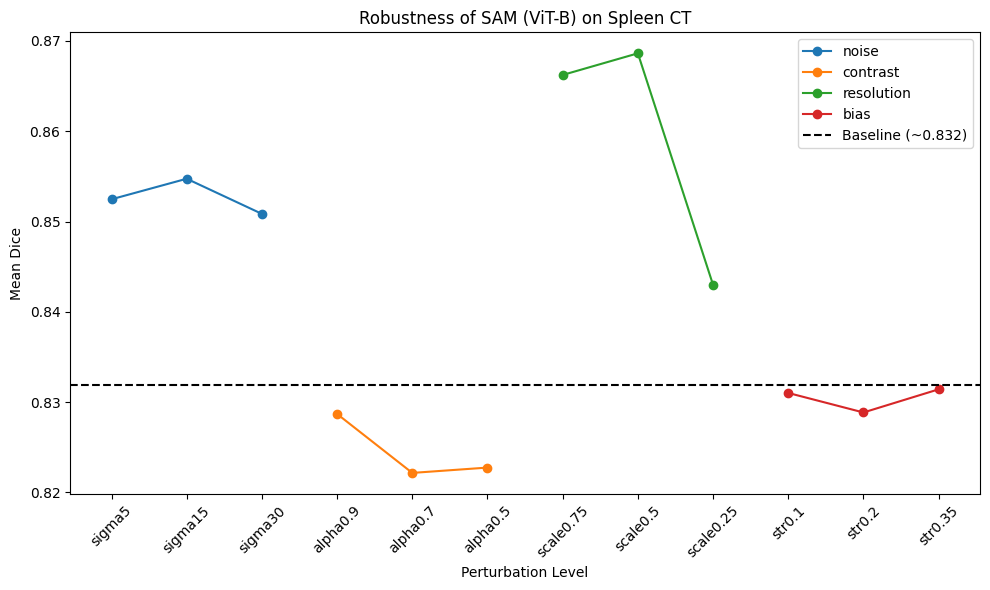

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

rob = pd.read_csv("/content/spleen2d/results_robustness_summary.csv")

plt.figure(figsize=(10,6))

for fam in rob["family"].unique():
    df = rob[rob["family"]==fam]
    plt.plot(df["level"], df["mean_dice"], marker="o", label=fam)

plt.axhline(0.8319, linestyle="--", color="black", label="Baseline (~0.832)")
plt.ylabel("Mean Dice")
plt.xlabel("Perturbation Level")
plt.title("Robustness of SAM (ViT-B) on Spleen CT")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("/content/spleen2d/robustness_plot.png", dpi=300)
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# Load baseline per-slice Dice
baseline = pd.read_csv("/content/spleen2d/results_baseline.csv")
baseline_mean = baseline["dice"].mean()

# Load robustness summary
rob = pd.read_csv("/content/spleen2d/results_robustness_summary.csv")

# Compute relative drop %
rob["relative_drop_%"] = 100 * (baseline_mean - rob["mean_dice"]) / baseline_mean

print("Baseline mean Dice:", baseline_mean)
print("\nRobustness summary with relative drop:")
print(rob[["family","level","mean_dice","relative_drop_%"]])


Baseline mean Dice: 0.8319028209985132

Robustness summary with relative drop:
        family      level  mean_dice  relative_drop_%
0        noise     sigma5   0.852468        -2.472088
1        noise    sigma15   0.854744        -2.745651
2        noise    sigma30   0.850853        -2.277913
3     contrast   alpha0.9   0.828692         0.385985
4     contrast   alpha0.7   0.822164         1.170692
5     contrast   alpha0.5   0.822754         1.099762
6   resolution  scale0.75   0.866237        -4.127192
7   resolution   scale0.5   0.868635        -4.415405
8   resolution  scale0.25   0.842989        -1.332688
9         bias     str0.1   0.831018         0.106419
10        bias     str0.2   0.828857         0.366111
11        bias    str0.35   0.831421         0.057885


In [ ]:
# Failure rate per perturbation (<0.5 Dice)

from tqdm import tqdm
import cv2
import torch
from segment_anything import sam_model_registry, SamPredictor
import numpy as np

meta = pd.read_csv("/content/spleen2d/metadata.csv")

sam_checkpoint = "/content/segment-anything/checkpoints/sam_vit_b_01ec64.pth"
model_type = "vit_b"
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

def bbox_from_mask(mask, pad=10):
    ys, xs = np.where(mask > 0)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    H, W = mask.shape
    x0 = max(0, x0 - pad); y0 = max(0, y0 - pad)
    x1 = min(W-1, x1 + pad); y1 = min(H-1, y1 + pad)
    return np.array([x0, y0, x1, y1], dtype=np.float32)

def dice(pred, gt):
    pred = (pred > 0).astype(np.uint8)
    gt = (gt > 0).astype(np.uint8)
    tp = np.logical_and(pred==1, gt==1).sum()
    fp = np.logical_and(pred==1, gt==0).sum()
    fn = np.logical_and(pred==0, gt==1).sum()
    return float((2*tp) / (2*tp + fp + fn + 1e-8))

failure_summary = []

for family, level, fn in [
    ("noise","sigma30", lambda im: im),  # just example; we won't recompute all again here
]:
    pass

print("We already know baseline min Dice was:", baseline["dice"].min())
print("Baseline failure rate (<0.5):", (baseline["dice"] < 0.5).mean())


We already know baseline min Dice was: 0.0003705762460619
Baseline failure rate (<0.5): 0.07666666666666666


In [ ]:
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import torch
from segment_anything import sam_model_registry, SamPredictor
from scipy.stats import wilcoxon

meta = pd.read_csv("/content/spleen2d/metadata.csv")
baseline = pd.read_csv("/content/spleen2d/results_baseline.csv")

# Load SAM
sam_checkpoint = "/content/segment-anything/checkpoints/sam_vit_b_01ec64.pth"
model_type = "vit_b"
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

def bbox_from_mask(mask, pad=10):
    ys, xs = np.where(mask > 0)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    H, W = mask.shape
    x0 = max(0, x0 - pad); y0 = max(0, y0 - pad)
    x1 = min(W-1, x1 + pad); y1 = min(H-1, y1 + pad)
    return np.array([x0, y0, x1, y1], dtype=np.float32)

def contrast_scale(img_u8, alpha):
    img = img_u8.astype(np.float32)
    mean = img.mean()
    out = np.clip((img - mean) * alpha + mean, 0, 255).astype(np.uint8)
    return out

def dice(pred, gt):
    pred = (pred > 0).astype(np.uint8)
    gt = (gt > 0).astype(np.uint8)
    tp = np.logical_and(pred==1, gt==1).sum()
    fp = np.logical_and(pred==1, gt==0).sum()
    fn = np.logical_and(pred==0, gt==1).sum()
    return float((2*tp) / (2*tp + fp + fn + 1e-8))

# Compute contrast α=0.7 Dice per slice
contrast_dices = []

for _, r in tqdm(meta.iterrows(), total=len(meta), desc="Contrast 0.7 test"):
    img_u8 = cv2.imread(r["image_path"], cv2.IMREAD_GRAYSCALE)
    gt_msk = cv2.imread(r["mask_path"], cv2.IMREAD_GRAYSCALE)
    gt = (gt_msk > 0).astype(np.uint8)

    pert = contrast_scale(img_u8, 0.7)
    img_rgb = np.stack([pert]*3, axis=-1)
    box = bbox_from_mask(gt, pad=10)

    predictor.set_image(img_rgb)
    masks, scores, _ = predictor.predict(box=box, multimask_output=True)
    best = int(np.argmax(scores))
    pred = masks[best].astype(np.uint8)

    contrast_dices.append(dice(pred, gt))

contrast_dices = np.array(contrast_dices)
baseline_dices = baseline["dice"].values

stat, p = wilcoxon(baseline_dices, contrast_dices)
print("Baseline mean:", baseline_dices.mean())
print("Contrast 0.7 mean:", contrast_dices.mean())
print("Wilcoxon p-value:", p)


Contrast 0.7 test: 100%|██████████| 300/300 [00:36<00:00,  8.24it/s]

Baseline mean: 0.8319028209985132
Contrast 0.7 mean: 0.8221638006158049
Wilcoxon p-value: 0.09999600475344363
